# Beta ablations

Root: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code
Beta ablation: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results_clean/generalization/final_linear_5grid_tabular_beta_ablation.csv FOUND
deterministic baseline: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results_clean/generalization/final_linear_5grid_rbf_grid_search_best.csv FOUND
stochastic baseline: /home/mauro/Desktop/EMAI/Ljubljana/Thesis/Code/data/results_clean/generalization/final_linear_5grid_stochastic_rbf_grid_search_best.csv FOUND

Using baseline source: grids best CSV


,problem,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward
0,deterministic,1.00,1.00,0.864131,0.864131
1,stochastic,0.97,0.92,-0.259688,-0.330850



Top beta-ablation configurations per problem:


,problem,beta_update,T,eta,rho,beta_projection_radius,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,greedy_success_rate_delta,solver_success_rate_delta,greedy_avg_reward_delta,solver_avg_reward_delta,elapsed_seconds
0,deterministic,projected_gradient,4000,0.0010,0.05,0.5,1.00,0.88,0.93000,0.77770,0.00,-0.12,0.065869,-0.086431,495.738294
1,deterministic,projected_gradient,4000,0.0010,0.05,10.0,1.00,0.88,0.93000,0.77770,0.00,-0.12,0.065869,-0.086431,536.661386
2,deterministic,projected_gradient,4000,0.0010,0.05,5.0,1.00,0.88,0.93000,0.77770,0.00,-0.12,0.065869,-0.086431,553.193845
3,deterministic,projected_gradient,4000,0.0010,0.05,2.0,1.00,0.88,0.93000,0.77770,0.00,-0.12,0.065869,-0.086431,735.662701
4,deterministic,projected_gradient,4000,0.0010,0.05,1.0,1.00,0.88,0.93000,0.77770,0.00,-0.12,0.065869,-0.086431,1171.532972
5,deterministic,projected_gradient,4000,0.0010,0.05,NaN,1.00,0.88,0.93000,0.77770,0.00,-0.12,0.065869,-0.086431,1242.488253
6,deterministic,projected_gradient,3000,0.0010,0.05,0.5,1.00,0.83,0.93000,0.72010,0.00,-0.17,0.065869,-0.144031,352.621608
7,deterministic,projected_gradient,3000,0.0010,0.05,1.0,1.00,0.83,0.93000,0.72010,0.00,-0.17,0.065869,-0.144031,355.200804
8,deterministic,projected_gradient,3000,0.0010,0.05,10.0,1.00,0.83,0.93000,0.72010,0.00,-0.17,0.065869,-0.144031,457.968055
9,deterministic,projected_gradient,3000,0.0010,0.05,2.0,1.00,0.83,0.93000,0.72010,0.00,-0.17,0.065869,-0.144031,700.917094



Best by beta update type:


,problem,beta_update,n,best_greedy_success,best_solver_success,best_greedy_reward,best_solver_reward,best_greedy_success_delta,best_greedy_reward_delta,median_seconds
1,deterministic,fenchel_mirror,56,1.00,0.78,0.9300,0.67480,0.00,0.065869,250.582319
2,deterministic,fogas_diag,175,1.00,0.79,0.9300,0.66940,0.00,0.065869,396.467564
3,deterministic,fogas_full,1,1.00,0.51,0.9300,0.34660,0.00,0.065869,106.977724
4,deterministic,projected_gradient,392,1.00,0.88,0.9300,0.77770,0.00,0.065869,258.455461
0,deterministic,fenchel_br,7,0.00,0.14,-0.2000,-0.05170,-1.00,-1.064131,498.764106
7,stochastic,fogas_diag,175,0.93,0.64,-0.0362,-0.81660,-0.04,0.223488,71.621572
6,stochastic,fenchel_mirror,56,0.91,0.74,-0.0226,-0.59765,-0.06,0.237088,80.062887
9,stochastic,projected_gradient,392,0.90,0.70,-0.0346,-0.52600,-0.07,0.225088,72.303375
5,stochastic,fenchel_br,7,0.19,0.30,-1.6824,-1.47600,-0.78,-1.422712,88.863340
8,stochastic,fogas_full,1,0.00,0.01,-2.0009,-1.99700,-0.97,-1.741212,57.519863


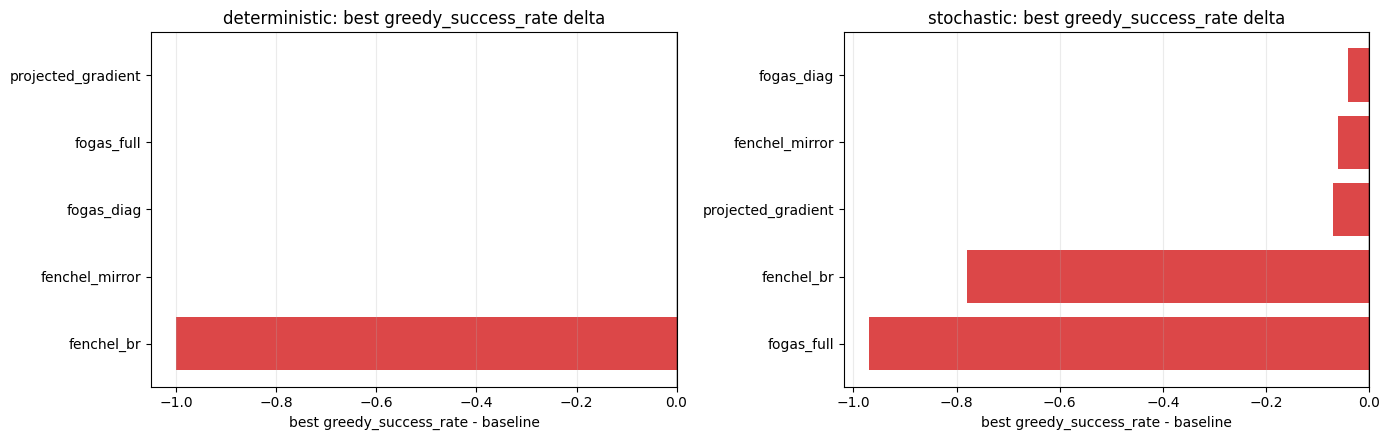

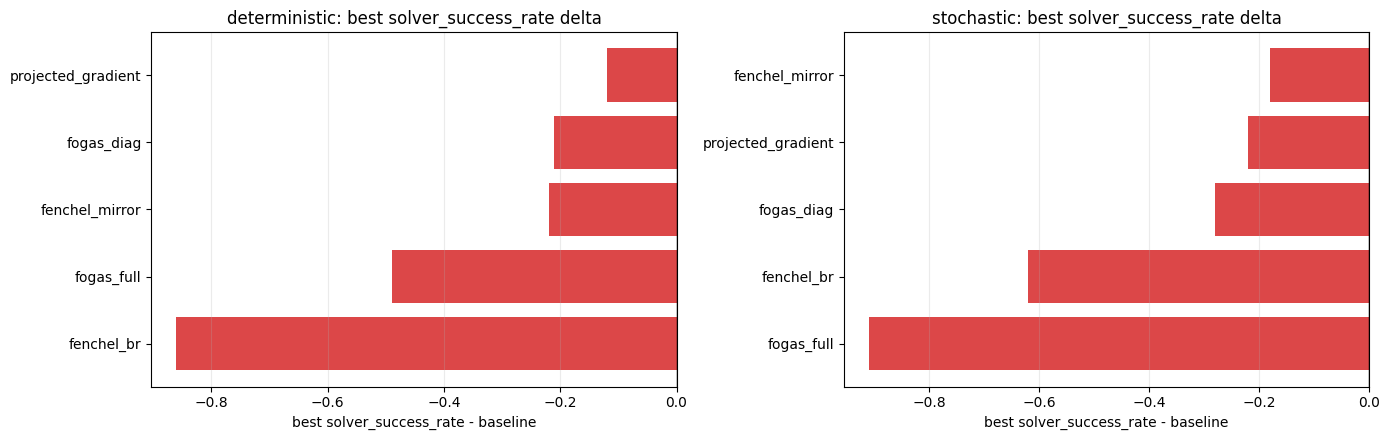

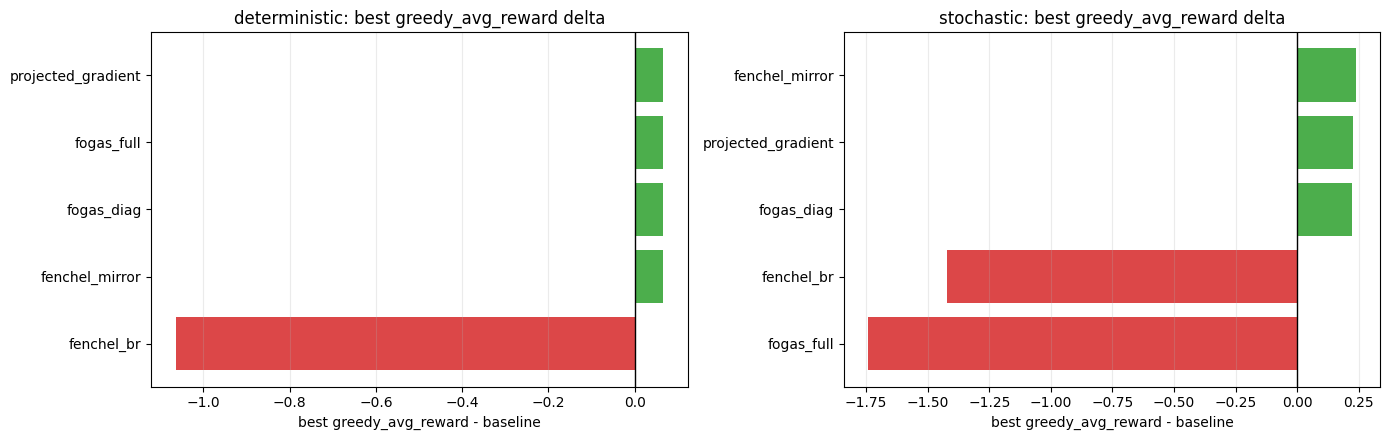

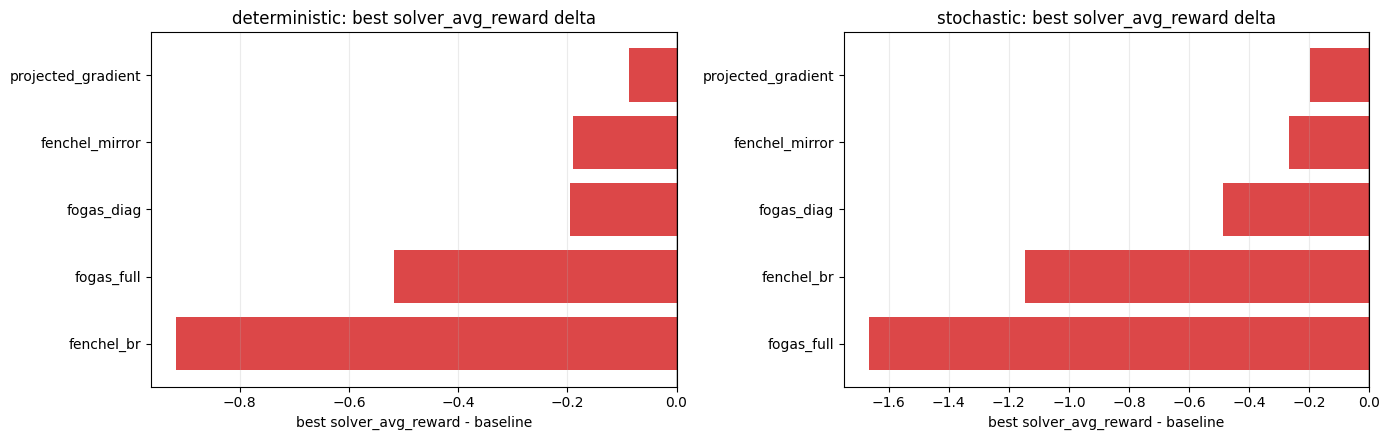

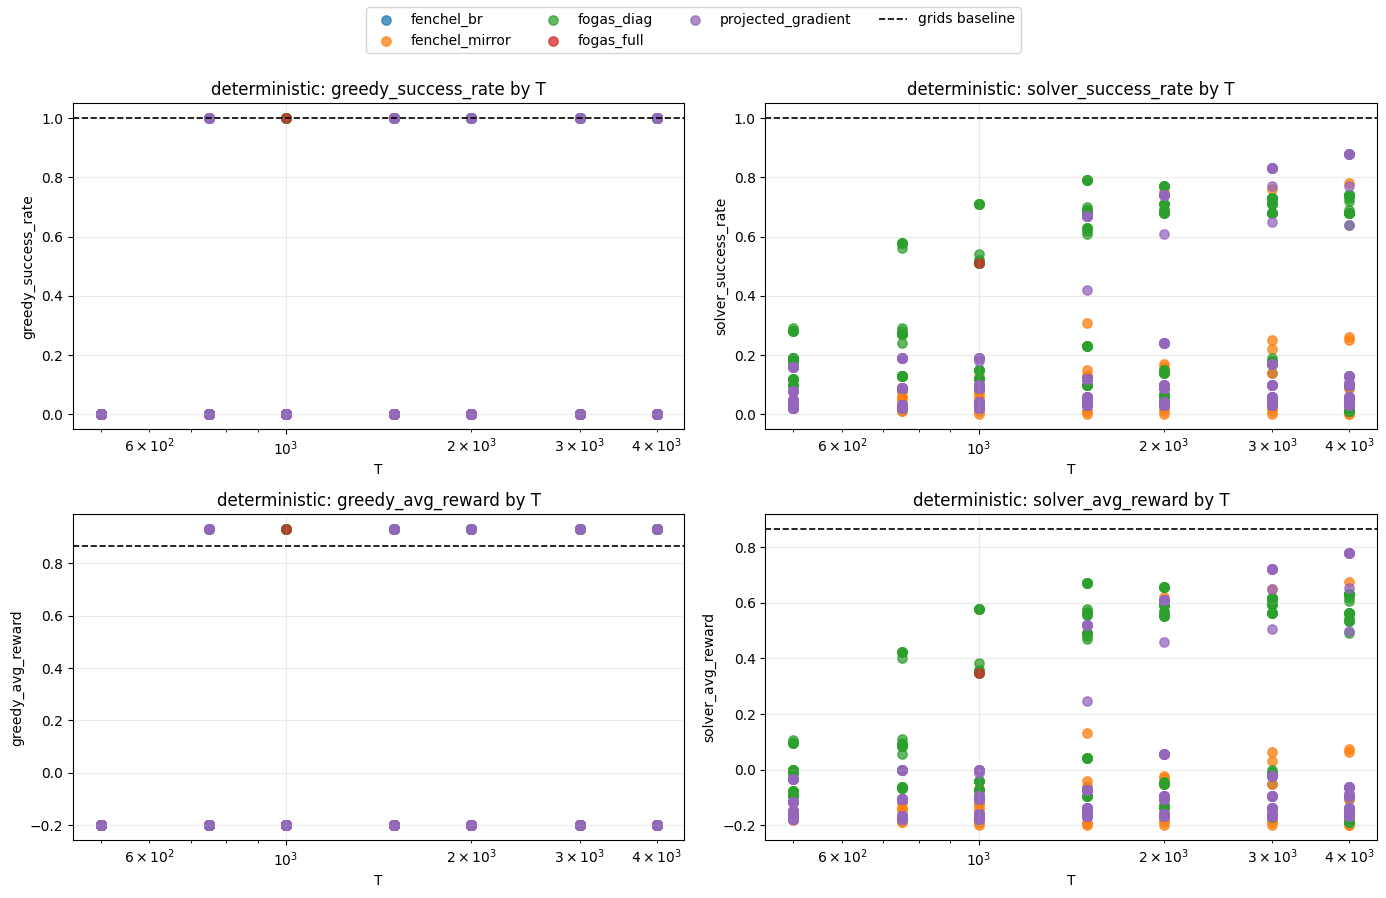

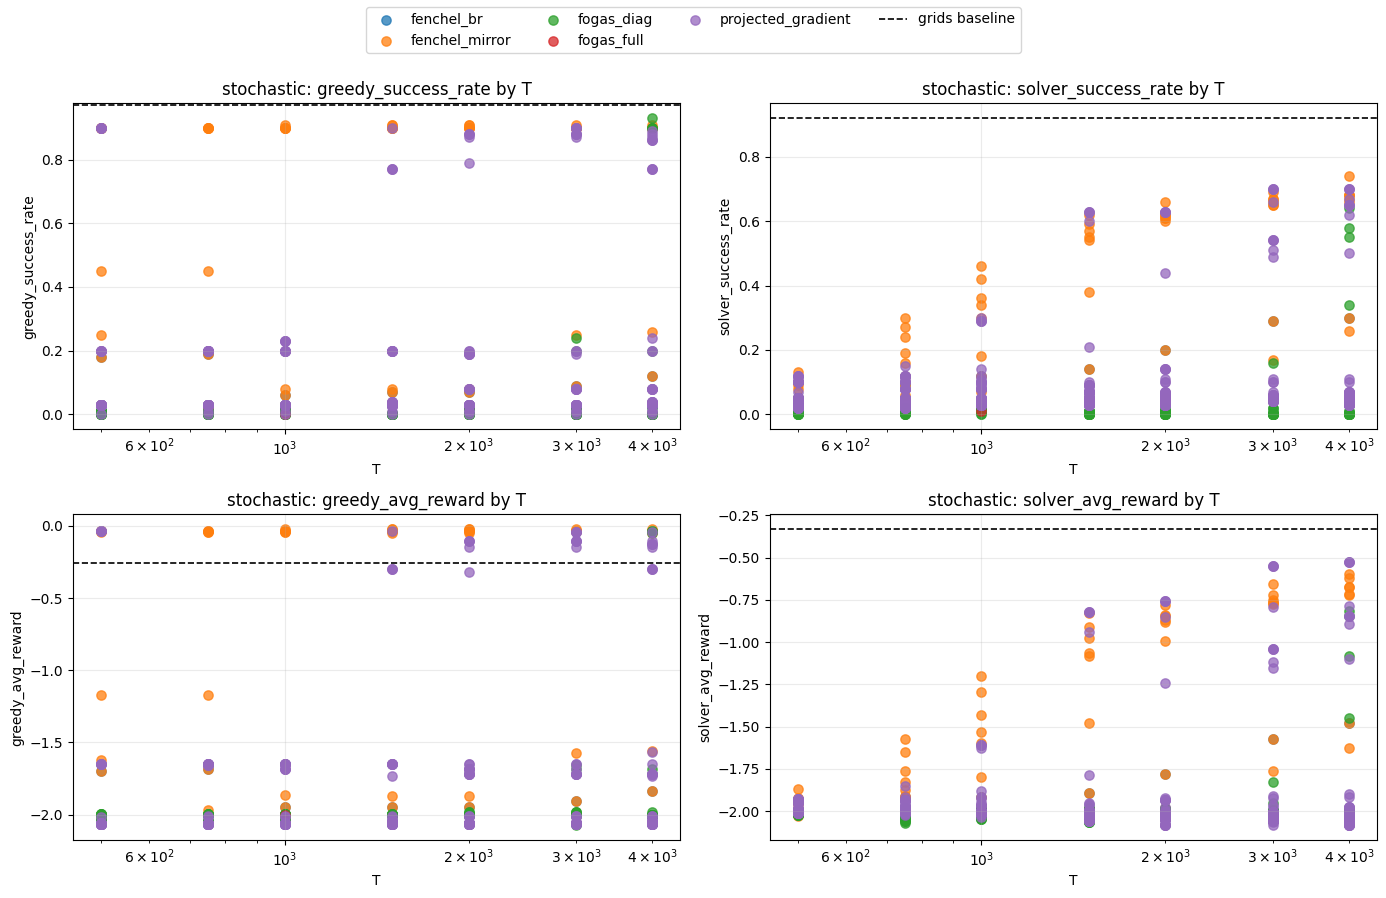

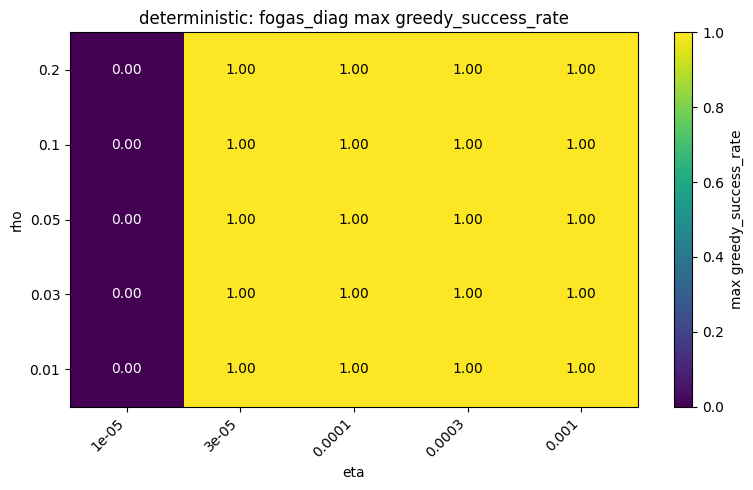

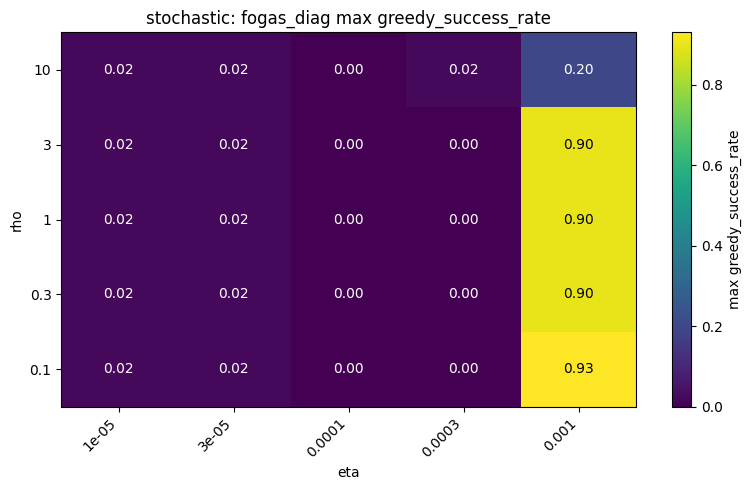

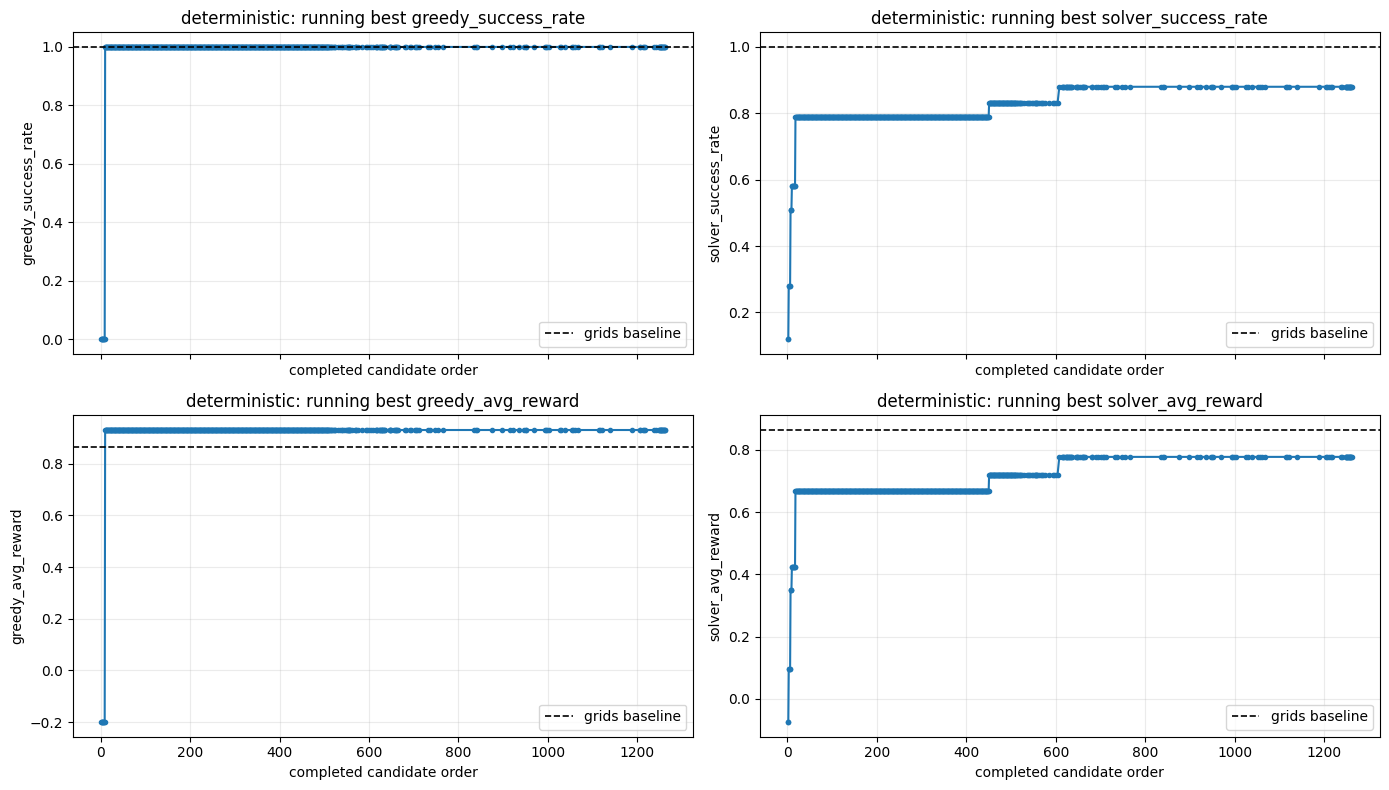

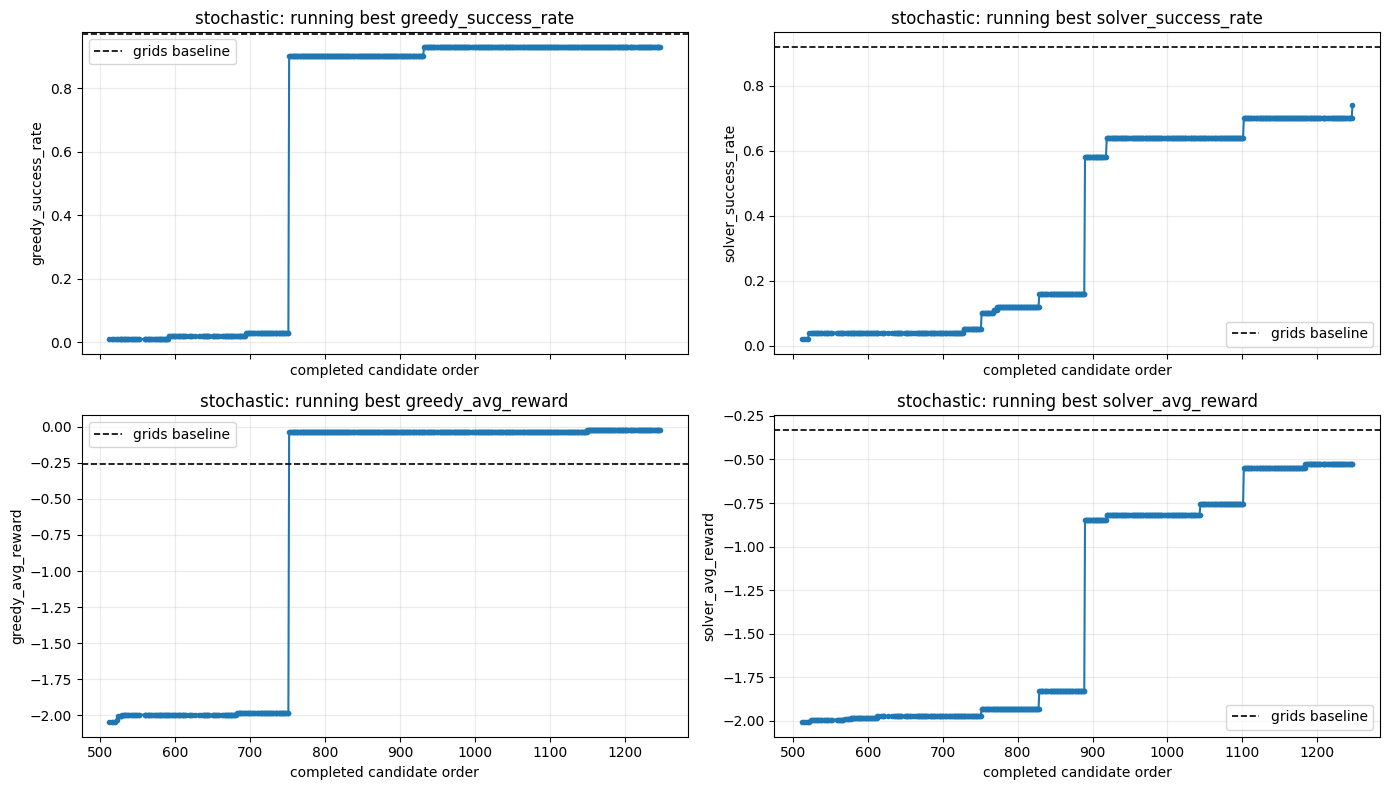

In [4]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def find_repo_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for p in [start, *start.parents]:
        if (p / "setup.py").exists() and (p / "data").exists():
            return p
    return Path.cwd()

ROOT = find_repo_root()
RESULTS_DIR = ROOT / "data" / "results_clean" / "generalization"

BETA_CSV = RESULTS_DIR / "final_linear_5grid_tabular_beta_ablation.csv"

# Baselines from the grids notebook / grid-search results.
BASELINE_CSVS = {
    "deterministic": RESULTS_DIR / "final_linear_5grid_rbf_grid_search_best.csv",
    "stochastic": RESULTS_DIR / "final_linear_5grid_stochastic_rbf_grid_search_best.csv",
}

METRICS = [
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
]

print("Root:", ROOT)
print("Beta ablation:", BETA_CSV, "FOUND" if BETA_CSV.exists() else "MISSING")
for problem, path in BASELINE_CSVS.items():
    print(f"{problem} baseline:", path, "FOUND" if path.exists() else "MISSING")

if not BETA_CSV.exists():
    raise FileNotFoundError(
        f"Missing beta ablation CSV: {BETA_CSV}\n"
        "Run:\n"
        "python experiments/fogas_generalization_clean/scripts/"
        "grid_search_final_linear_5grid_tabular_beta_ablation.py --resume"
    )

df = pd.read_csv(BETA_CSV)
if "status" in df.columns:
    df = df[df["status"].eq("ok")].copy()

if df.empty:
    raise ValueError("Beta ablation CSV has no successful rows.")

# Normalize metric names.
rename = {
    "solver_avg_return": "solver_avg_reward",
    "greedy_avg_return": "greedy_avg_reward",
}
df = df.rename(columns={k: v for k, v in rename.items() if k in df.columns})

df["run_order"] = df["run_idx"] if "run_idx" in df.columns else np.arange(len(df))
df["radius_label"] = df.get("beta_projection_radius", pd.Series(np.nan, index=df.index)).fillna("none").astype(str)
df["config"] = (
    df["beta_update"].astype(str)
    + " | T=" + df["T"].astype(str)
    + " eta=" + df["eta"].map(lambda x: f"{x:g}")
    + " rho=" + df["rho"].map(lambda x: f"{x:g}")
    + " radius=" + df["radius_label"]
)

# Internal baseline: the beta-ablation fogas_full row.
internal_baseline = (
    df[df["beta_update"].eq("fogas_full")]
    .sort_values(["problem", "run_order"])
    .groupby("problem", as_index=False)
    .first()
)

# External baseline: best rows from grids notebook CSVs.
baseline_rows = []
for problem, path in BASELINE_CSVS.items():
    if not path.exists():
        continue

    b = pd.read_csv(path).rename(columns=rename)
    if "status" in b.columns:
        b = b[b["status"].eq("ok")].copy()
    if b.empty:
        continue

    sort_cols = [c for c in ["greedy_success_rate", "solver_success_rate", "greedy_avg_reward", "solver_avg_reward"] if c in b.columns]
    b = b.sort_values(sort_cols, ascending=[False] * len(sort_cols)).head(1).copy()
    b["problem"] = problem
    baseline_rows.append(b)

external_baseline = pd.concat(baseline_rows, ignore_index=True, sort=False) if baseline_rows else pd.DataFrame()

# If external baseline is missing, fall back to internal baseline.
baseline = external_baseline if not external_baseline.empty else internal_baseline.copy()
baseline_source = "grids best CSV" if not external_baseline.empty else "beta ablation fogas_full row"

print("\nUsing baseline source:", baseline_source)
display(baseline[["problem"] + [c for c in METRICS if c in baseline.columns]])

for metric in METRICS:
    b = baseline[["problem", metric]].rename(columns={metric: f"{metric}_baseline"})
    df = df.merge(b, on="problem", how="left")
    df[f"{metric}_delta"] = df[metric] - df[f"{metric}_baseline"]

# Best rows overall.
best = (
    df.sort_values(
        ["problem", "greedy_success_rate", "solver_success_rate", "greedy_avg_reward", "solver_avg_reward", "elapsed_seconds"],
        ascending=[True, False, False, False, False, True],
    )
    .groupby("problem", as_index=False)
    .head(15)
)

print("\nTop beta-ablation configurations per problem:")
display(best[
    ["problem", "beta_update", "T", "eta", "rho", "beta_projection_radius"]
    + METRICS
    + [f"{m}_delta" for m in METRICS]
    + ["elapsed_seconds"]
])

# Best per beta update.
summary = (
    df.groupby(["problem", "beta_update"], dropna=False)
    .agg(
        n=("beta_update", "size"),
        best_greedy_success=("greedy_success_rate", "max"),
        best_solver_success=("solver_success_rate", "max"),
        best_greedy_reward=("greedy_avg_reward", "max"),
        best_solver_reward=("solver_avg_reward", "max"),
        best_greedy_success_delta=("greedy_success_rate_delta", "max"),
        best_greedy_reward_delta=("greedy_avg_reward_delta", "max"),
        median_seconds=("elapsed_seconds", "median"),
    )
    .reset_index()
    .sort_values(["problem", "best_greedy_success", "best_greedy_reward"], ascending=[True, False, False])
)

print("\nBest by beta update type:")
display(summary)

# 1. Bar plots: best delta vs grids baseline by beta update.
for metric in ["greedy_success_rate", "solver_success_rate", "greedy_avg_reward", "solver_avg_reward"]:
    delta_col = f"{metric}_delta"
    fig, axes = plt.subplots(1, df["problem"].nunique(), figsize=(7 * df["problem"].nunique(), 4.5), squeeze=False)

    for ax, problem in zip(axes[0], sorted(df["problem"].unique())):
        g = (
            df[df["problem"].eq(problem)]
            .groupby("beta_update", dropna=False)[delta_col]
            .max()
            .sort_values()
        )
        colors = ["tab:green" if v >= 0 else "tab:red" for v in g.values]

        ax.barh(g.index.astype(str), g.values, color=colors, alpha=0.85)
        ax.axvline(0, color="black", linewidth=1)
        ax.set_title(f"{problem}: best {metric} delta")
        ax.set_xlabel(f"best {metric} - baseline")
        ax.grid(True, axis="x", alpha=0.25)

    plt.tight_layout()
    plt.show()

# 2. Scatter plots: all configurations, colored by beta update, baseline as dashed line.
for problem in sorted(df["problem"].unique()):
    sub = df[df["problem"].eq(problem)].copy()

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        for beta_update, g in sub.groupby("beta_update"):
            ax.scatter(g["T"], g[metric], s=45, alpha=0.75, label=beta_update)

        bval = baseline[baseline["problem"].eq(problem)][metric]
        if len(bval) and pd.notna(bval.iloc[0]):
            ax.axhline(bval.iloc[0], color="black", linestyle="--", linewidth=1.2, label="grids baseline")

        ax.set_xscale("log")
        ax.set_title(f"{problem}: {metric} by T")
        ax.set_xlabel("T")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper center", ncols=4)
    fig.tight_layout(rect=[0, 0, 1, 0.93])
    plt.show()

# 3. Eta/rho heatmaps for each beta update: max greedy success.
for problem in sorted(df["problem"].unique()):
    for beta_update in sorted(df["beta_update"].dropna().unique()):
        sub = df[df["problem"].eq(problem) & df["beta_update"].eq(beta_update)].copy()
        if sub.empty or sub["eta"].nunique() < 2 or sub["rho"].nunique() < 2:
            continue

        pivot = sub.pivot_table(
            index="rho",
            columns="eta",
            values="greedy_success_rate",
            aggfunc="max",
        ).sort_index().sort_index(axis=1)

        fig, ax = plt.subplots(figsize=(8, 5))
        im = ax.imshow(pivot.values, aspect="auto", origin="lower", cmap="viridis")

        ax.set_title(f"{problem}: {beta_update} max greedy_success_rate")
        ax.set_xlabel("eta")
        ax.set_ylabel("rho")
        ax.set_xticks(np.arange(len(pivot.columns)))
        ax.set_xticklabels([f"{x:g}" for x in pivot.columns], rotation=45, ha="right")
        ax.set_yticks(np.arange(len(pivot.index)))
        ax.set_yticklabels([f"{x:g}" for x in pivot.index])

        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                val = pivot.values[i, j]
                if pd.notna(val):
                    ax.text(j, i, f"{val:.2f}", ha="center", va="center", color="white" if val < 0.65 else "black")

        fig.colorbar(im, ax=ax, label="max greedy_success_rate")
        plt.tight_layout()
        plt.show()

# 4. Running best while ablation file grows.
for problem in sorted(df["problem"].unique()):
    sub = df[df["problem"].eq(problem)].sort_values("run_order")

    fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
    axes = axes.ravel()

    for ax, metric in zip(axes, METRICS):
        ax.plot(sub["run_order"], sub[metric].cummax(), marker=".", linewidth=1.5)

        bval = baseline[baseline["problem"].eq(problem)][metric]
        if len(bval) and pd.notna(bval.iloc[0]):
            ax.axhline(bval.iloc[0], color="black", linestyle="--", linewidth=1.2, label="grids baseline")

        ax.set_title(f"{problem}: running best {metric}")
        ax.set_xlabel("completed candidate order")
        ax.set_ylabel(metric)
        ax.grid(True, alpha=0.25)
        ax.legend()

    plt.tight_layout()
    plt.show()

In [7]:
from pathlib import Path
import pandas as pd

df = pd.read_csv(BETA_CSV)

cols = [
    "problem",
    "beta_update",
    "status",
    "T",
    "eta",
    "rho",
    "greedy_success_rate",
    "solver_success_rate",
    "greedy_avg_reward",
    "solver_avg_reward",
    "elapsed_seconds",
    "run_idx",
]

fogas_full_rows = (
    df[df["beta_update"].eq("fogas_full")]
    .sort_values(["problem", "run_idx"])
)

display(fogas_full_rows[cols])

,problem,beta_update,status,T,eta,rho,greedy_success_rate,solver_success_rate,greedy_avg_reward,solver_avg_reward,elapsed_seconds,run_idx
112,deterministic,fogas_full,ok,1000,0.0001,0.05,1.0,0.51,0.9300,0.3466,106.977724,13
1155,stochastic,fogas_full,ok,1000,0.0001,1.00,0.0,0.01,-2.0009,-1.9970,57.519863,524


In [ ]:
No